In [2]:
import gpboost as gpb
import pandas as pd
import numpy as np
# Load data
data = pd.read_csv('C:/Files/GLAN_DATA/first_wave/downscale_data_60/data_with_activity_sequence_all_recod_downsampling_activity_travel.csv')
data = data[data['time_weight'] >= 5]
data = data[data['tree_height'] >= 0]
print(data.shape)
pred_vars = ['household_income', 'age', 'gender', 'education_level', 'employment_status', 'neighborhood_type',
             'work_study', 'housework', 'personal_affair', 'leisure',
             'travel', 'transportation', 'residence', 'industry', 'company', 'shopping',
             'restaurant', 'life_service', 'education_culture', 'entertainment', 'sport_fitness',
             'recreation_tourism', 'healthcare', 'workday', 'time_hour', 'mobility_status',
             'time_nonflexibility', 'home_ornot', 'POI_density', 'POI_diversity', "tree_height"]

(8427, 51)


In [5]:
import optuna
from optuna.samplers import TPESampler
import gpboost as gpb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold

# Prepare 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=666)
fold_results = []

# Define the Optuna objective function (to be used per fold)
def create_objective(data_train_fold, data_val_fold):
    def objective(trial):
        params = {
            'num_boost_round': trial.suggest_int('num_boost_round', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 18),
            'num_leaves': trial.suggest_int('num_leaves', 20, 400),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
            'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 10),
            'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 10),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1),
            'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
            'min_sum_hessian_in_leaf': trial.suggest_float('min_sum_hessian_in_leaf', 0.001, 5.0, log=True),
            'verbose': 0,
            'objective': 'regression',
            'metric': 'mse'
        }

        # Create GPModel and Dataset for training
        gp_model = gpb.GPModel(group_data=data_train_fold['pid'], likelihood='gaussian')
        data_bst = gpb.Dataset(data=data_train_fold[pred_vars], label=data_train_fold['noise_norm'])

        # Create validation set
        data_bst_valid = gpb.Dataset(data=data_val_fold[pred_vars], label=data_val_fold['noise_norm'], reference=data_bst)

        # Set prediction data for gp_model
        gp_model.set_prediction_data(group_data_pred=data_val_fold['pid'])

        # Train the model with early stopping
        gpbst = gpb.train(
            params=params,
            train_set=data_bst,
            gp_model=gp_model,
            valid_sets=[data_bst_valid],
            valid_names=['valid'],
            early_stopping_rounds=50
        )

        # Predict on validation set
        pred_val = gpbst.predict(data=data_val_fold[pred_vars], group_data_pred=data_val_fold['pid'], pred_latent=False)['response_mean']

        # Compute MSE and R²
        mse = mean_squared_error(data_val_fold['noise_norm'], pred_val)
        r2 = r2_score(data_val_fold['noise_norm'], pred_val)
        print(f"Trial {trial.number} - MSE: {mse:.4f}, R²: {r2:.4f}")

        return r2

    return objective

# Perform optimization for each fold
for fold, (train_idx, val_idx) in enumerate(kf.split(data)):
    print(f"Starting optimization for fold {fold + 1}")
    data_train_fold = data.iloc[train_idx]
    data_val_fold = data.iloc[val_idx]

    # Create study for this fold
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=6666), study_name=f'optimization_fold_{fold + 1}')
    objective = create_objective(data_train_fold, data_val_fold)
    study.optimize(objective, n_trials=500)

    # Get best parameters and best R² (opt_val_r2)
    best_params = study.best_params
    opt_val_r2 = study.best_value

    # Retrain with best params and early stopping to compute metrics
    final_params = best_params.copy()
    final_params.update({'verbose': 0, 'objective': 'regression', 'metric': 'mse'})

    gp_model = gpb.GPModel(group_data=data_train_fold['pid'], likelihood='gaussian')
    data_bst = gpb.Dataset(data=data_train_fold[pred_vars], label=data_train_fold['noise_norm'])
    data_bst_valid = gpb.Dataset(data=data_val_fold[pred_vars], label=data_val_fold['noise_norm'], reference=data_bst)
    gp_model.set_prediction_data(group_data_pred=data_val_fold['pid'])

    gpbst = gpb.train(
        params=final_params,
        train_set=data_bst,
        gp_model=gp_model,
        valid_sets=[data_bst_valid],
        valid_names=['valid'],
        early_stopping_rounds=50
    )

    # Predict on train
    pred_train = gpbst.predict(data=data_train_fold[pred_vars], group_data_pred=data_train_fold['pid'], pred_latent=False)['response_mean']
    train_mse = mean_squared_error(data_train_fold['noise_norm'], pred_train)
    train_r2 = r2_score(data_train_fold['noise_norm'], pred_train)

    # Predict on val
    pred_val = gpbst.predict(data=data_val_fold[pred_vars], group_data_pred=data_val_fold['pid'], pred_latent=False)['response_mean']
    val_mse = mean_squared_error(data_val_fold['noise_norm'], pred_val)
    val_r2 = r2_score(data_val_fold['noise_norm'], pred_val)

    # Store results
    fold_results.append({
        'fold': fold + 1,
        'best_params': best_params,
        'train_mse': train_mse,
        'train_r2': train_r2,
        'val_mse': val_mse,
        'val_r2': val_r2
    })

    print(f"Fold {fold + 1} - Best Params: {best_params}")
    print(f"Fold {fold + 1} - Train MSE: {train_mse:.4f}")
    print(f"Fold {fold + 1} - Train R²: {train_r2:.4f}")
    print(f"Fold {fold + 1} - Val MSE: {val_mse:.4f}")
    print(f"Fold {fold + 1} - Val R²: {val_r2:.4f}")

# Optionally, print all fold results
print("All fold results:")
for result in fold_results:
    print(result)

[I 2025-09-29 14:00:56,865] A new study created in memory with name: optimization_fold_1


Starting optimization for fold 1
[1]	valid's l2: 0.644335
[2]	valid's l2: 0.441845
[3]	valid's l2: 0.239485
[4]	valid's l2: 0.180593
[5]	valid's l2: 0.174698
[6]	valid's l2: 0.20231
[7]	valid's l2: 0.233128
[8]	valid's l2: 0.276196
[9]	valid's l2: 0.307482
[10]	valid's l2: 0.338593
[11]	valid's l2: 0.359967
[12]	valid's l2: 0.37322
[13]	valid's l2: 0.41426
[14]	valid's l2: 0.430329
[15]	valid's l2: 0.477907
[16]	valid's l2: 0.494179
[17]	valid's l2: 0.534563
[18]	valid's l2: 0.567978
[19]	valid's l2: 0.584781
[20]	valid's l2: 0.610765
[21]	valid's l2: 0.642261
[22]	valid's l2: 0.657372
[23]	valid's l2: 0.694064


C:\anaconda3\envs\torch\lib\site-packages\gpboost\engine.py:183: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  _log_warning("Found `{}` in params. Will use it instead of argument".format(alias))


[24]	valid's l2: 0.727364
[25]	valid's l2: 0.731551
[26]	valid's l2: 0.776784
[27]	valid's l2: 0.770961
[28]	valid's l2: 0.778148
[29]	valid's l2: 0.814887
[30]	valid's l2: 0.803877
[31]	valid's l2: 0.84519
[32]	valid's l2: 0.809369
[33]	valid's l2: 0.856743
[34]	valid's l2: 0.841273
[35]	valid's l2: 0.913113
[36]	valid's l2: 0.905547
[37]	valid's l2: 0.947337
[38]	valid's l2: 0.975925
[39]	valid's l2: 1.02488
[40]	valid's l2: 1.06196
[41]	valid's l2: 1.06925
[42]	valid's l2: 1.13069
[43]	valid's l2: 1.14914
[44]	valid's l2: 1.2089
[45]	valid's l2: 1.22994
[46]	valid's l2: 1.2875
[47]	valid's l2: 1.31444
[48]	valid's l2: 1.32529
[49]	valid's l2: 1.34143
[50]	valid's l2: 1.40246
[51]	valid's l2: 1.4252


[I 2025-09-29 14:00:57,300] Trial 0 finished with value: -9.173773810021599 and parameters: {'num_boost_round': 223, 'learning_rate': 0.20096721915655422, 'max_depth': 12, 'num_leaves': 312, 'min_data_in_leaf': 18, 'lambda_l1': 4.278890484619808, 'lambda_l2': 9.080694704080548, 'feature_fraction': 0.7011912706368676, 'min_gain_to_split': 0.9920529917743516, 'min_sum_hessian_in_leaf': 1.7058922588526466}. Best is trial 0 with value: -9.173773810021599.


...

[1]	valid's l2: 0.0124249
[2]	valid's l2: 0.0113426
[3]	valid's l2: 0.0108705
[4]	valid's l2: 0.0106685
[5]	valid's l2: 0.0106432
[6]	valid's l2: 0.0106535
[7]	valid's l2: 0.0106344
[8]	valid's l2: 0.0106002
[9]	valid's l2: 0.0105806
[10]	valid's l2: 0.0105664
[11]	valid's l2: 0.0106274
[12]	valid's l2: 0.0105687
[13]	valid's l2: 0.0105487
[14]	valid's l2: 0.0105995
[15]	valid's l2: 0.0105665
[16]	valid's l2: 0.0105068
[17]	valid's l2: 0.0105267
[18]	valid's l2: 0.0105047
[19]	valid's l2: 0.0105157
[20]	valid's l2: 0.0105743
[21]	valid's l2: 0.0105681
[22]	valid's l2: 0.0105719
[23]	valid's l2: 0.0105646
[24]	valid's l2: 0.010567
[25]	valid's l2: 0.0105745
[26]	valid's l2: 0.0106303
[27]	valid's l2: 0.010605
[28]	valid's l2: 0.0106009
[29]	valid's l2: 0.0106467
[30]	valid's l2: 0.0107091
[31]	valid's l2: 0.0107186
[32]	valid's l2: 0.0107797
[33]	valid's l2: 0.0107511
[34]	valid's l2: 0.0107833
[35]	valid's l2: 0.0107226
[36]	valid's l2: 0.0107891
[37]	valid's l2: 0.0108517
[38]	valid's

[I 2025-09-29 14:07:36,765] Trial 497 finished with value: 0.2651182310415977 and parameters: {'num_boost_round': 419, 'learning_rate': 0.07756071553068132, 'max_depth': 3, 'num_leaves': 87, 'min_data_in_leaf': 49, 'lambda_l1': 2.071051368764311, 'lambda_l2': 8.615325861439116, 'feature_fraction': 0.9595951309356527, 'min_gain_to_split': 0.1729399715350668, 'min_sum_hessian_in_leaf': 2.12587696650256}. Best is trial 207 with value: 0.4257324705132354.
C:\anaconda3\envs\torch\lib\site-packages\gpboost\engine.py:183: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  _log_warning("Found `{}` in params. Will use it instead of argument".format(alias))
[I 2025-09-29 14:07:36,903] Trial 498 finished with value: 0.29839431721810916 and parameters: {'num_boost_round': 307, 'learning_rate': 0.025868717725745394, 'max_depth': 3, 'num_leaves': 334, 'min_data_in_leaf': 69, 'lambda_l1': 1.5769173881096783, 'lambda_l2': 9.376779428713267, 'feature_fraction': 0.94804175

[23]	valid's l2: 0.0165932
[24]	valid's l2: 0.0563544
[25]	valid's l2: 0.0197764
[26]	valid's l2: 0.0656357
[27]	valid's l2: 0.0156423
[28]	valid's l2: 0.0513226
[29]	valid's l2: 0.0237071
[30]	valid's l2: 0.0659855
[31]	valid's l2: 0.0155522
[32]	valid's l2: 0.0488167
[33]	valid's l2: 0.0264359
[34]	valid's l2: 0.0623337
[35]	valid's l2: 0.0167229
[36]	valid's l2: 0.0580329
[37]	valid's l2: 0.0189253
[38]	valid's l2: 0.0665957
[39]	valid's l2: 0.0559263
[40]	valid's l2: 0.0276057
[41]	valid's l2: 0.0523321
[42]	valid's l2: 0.0255349
[43]	valid's l2: 0.0550591
[44]	valid's l2: 0.0247023
[45]	valid's l2: 0.0554612
[46]	valid's l2: 0.0238609
[47]	valid's l2: 0.0577323
[48]	valid's l2: 0.0239993
[49]	valid's l2: 0.0529015
[50]	valid's l2: 0.0268787
[51]	valid's l2: 0.0553608
[52]	valid's l2: 0.0254804
Early stopping, best iteration is:
[2]	valid's l2: 0.0129296
Trial 497 - MSE: 0.0132, R²: 0.2651
[1]	valid's l2: 0.0126582
[2]	valid's l2: 0.0127006
[3]	valid's l2: 0.0128173
[4]	valid's l2:

C:\anaconda3\envs\torch\lib\site-packages\gpboost\engine.py:183: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  _log_warning("Found `{}` in params. Will use it instead of argument".format(alias))
[I 2025-09-29 14:07:37,066] Trial 499 finished with value: 0.41090683779970394 and parameters: {'num_boost_round': 440, 'learning_rate': 0.00640212244020543, 'max_depth': 3, 'num_leaves': 209, 'min_data_in_leaf': 36, 'lambda_l1': 3.211153127393813, 'lambda_l2': 8.871167286042438, 'feature_fraction': 0.8886190251948152, 'min_gain_to_split': 0.15072882513608835, 'min_sum_hessian_in_leaf': 0.08398049384800282}. Best is trial 207 with value: 0.4257324705132354.
C:\anaconda3\envs\torch\lib\site-packages\gpboost\engine.py:183: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  _log_warning("Found `{}` in params. Will use it instead of argument".format(alias))


[1]	valid's l2: 0.0124884
[2]	valid's l2: 0.0113255
[3]	valid's l2: 0.0109196
[4]	valid's l2: 0.0107624
[5]	valid's l2: 0.0106418
[6]	valid's l2: 0.0106171
[7]	valid's l2: 0.0106407
[8]	valid's l2: 0.010608
[9]	valid's l2: 0.0106892
[10]	valid's l2: 0.0106742
[11]	valid's l2: 0.0106564
[12]	valid's l2: 0.0106482
[13]	valid's l2: 0.0106301
[14]	valid's l2: 0.0106335
[15]	valid's l2: 0.0106093
[16]	valid's l2: 0.0106105
[17]	valid's l2: 0.010591
[18]	valid's l2: 0.0105632
[19]	valid's l2: 0.0105906
[20]	valid's l2: 0.0105967
[21]	valid's l2: 0.0106155
[22]	valid's l2: 0.0105974
[23]	valid's l2: 0.0106145
[24]	valid's l2: 0.0106379
[25]	valid's l2: 0.0107052
[26]	valid's l2: 0.0106954
[27]	valid's l2: 0.0107763
[28]	valid's l2: 0.0107941
[29]	valid's l2: 0.0108088
[30]	valid's l2: 0.0107785
[31]	valid's l2: 0.0107766
[32]	valid's l2: 0.0107535
[33]	valid's l2: 0.0107231
[34]	valid's l2: 0.010735
[35]	valid's l2: 0.0107402
[36]	valid's l2: 0.0107378
[37]	valid's l2: 0.0107455
[38]	valid's 

In [1]:
import gpboost as gpb

# Recommended parameters based on median from 5-fold CV
final_params =  {
    'num_boost_round': 215,
    'learning_rate': 0.005328,
    'max_depth': 4,
    'num_leaves': 91,
    'min_data_in_leaf': 67,
    'lambda_l1': 4.4082,
    'lambda_l2': 4.3226,
    'feature_fraction': 0.9463,
    'min_gain_to_split': 0.5145,
    'min_sum_hessian_in_leaf': 0.0669,
    'verbose': 0,
    'objective': 'regression',
    'metric': 'mse'
}

# Retrain the final model with best params on full data_train
gp_model = gpb.GPModel(
    group_data=data['pid'],
    likelihood='gaussian'
)
data_bst = gpb.Dataset(data=data[pred_vars], label=data['compound_exposure_discordance'])

gpbst = gpb.train(
    params=final_params,
    train_set=data_bst,
    gp_model=gp_model
)

gp_model.summary()  # Estimated random effects model


C:\anaconda3\envs\torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'data' is not defined

In [5]:
from sklearn.metrics import mean_squared_error, r2_score
# Get covariance parameters: DataFrame with index 'Param.' and columns 'Error_term' and 'pid'
cov_pars = gp_model.get_cov_pars()
sigma2 = cov_pars.loc['Param.', 'Error_term']  # Residual variance
print(sigma2)
sigma_b2 = cov_pars.loc['Param.', 'pid']  # Random effect variance for 'pid'
print(sigma_b2)
# Compute predictions
y = data['compound_exposure_discordance'].values

# Fixed effects predictions (tree-boosting part)
fixed_pred = gpbst.predict(data=data[pred_vars], group_data_pred=data['pid'], pred_latent=True)['fixed_effect']

# Full predictions (fixed + random)
full_pred = gpbst.predict(data=data[pred_vars], group_data_pred=data['pid'], pred_latent=False)['response_mean']

# Compute var_fixed: variance of fixed effects predictions
var_fixed = np.var(fixed_pred)

# For ICC, marginal R2, conditional R2 using Nakagawa's approach
total_var = var_fixed + sigma_b2 + sigma2
icc = sigma_b2 / (sigma_b2 + sigma2)
marginal_r2 = var_fixed / total_var
conditional_r2 = (var_fixed + sigma_b2) / total_var

# Print the results
print(f"ICC: {icc:.4f}")
print(f"Marginal R²: {marginal_r2:.4f}")
print(f"Conditional R²: {conditional_r2:.4f}")

# Optional: Verify with R2 scores (should be close)
fixed_r2 = r2_score(y, fixed_pred)
full_r2 = r2_score(y, full_pred)
print(f"R² from fixed predictions: {fixed_r2:.4f} (approx. marginal R²)")
print(f"R² from full predictions: {full_r2:.4f} (approx. conditional R²)")

0.002343999212190267
0.0010480132462924755
ICC: 0.3090
Marginal R²: 0.7112
Conditional R²: 0.8005
R² from fixed predictions: 0.6801 (approx. marginal R²)
R² from full predictions: 0.7934 (approx. conditional R²)


In [6]:
import shap
shap_values = shap.TreeExplainer(gpbst).shap_values(data[pred_vars])
#feature_names = [ a + ": " + str(b) for a,b in zip(pred_vars, np.abs(shap_values).mean(0).round(5)) ]
#shap.summary_plot(shap_values, data[pred_vars], max_display=30, feature_names=feature_names)

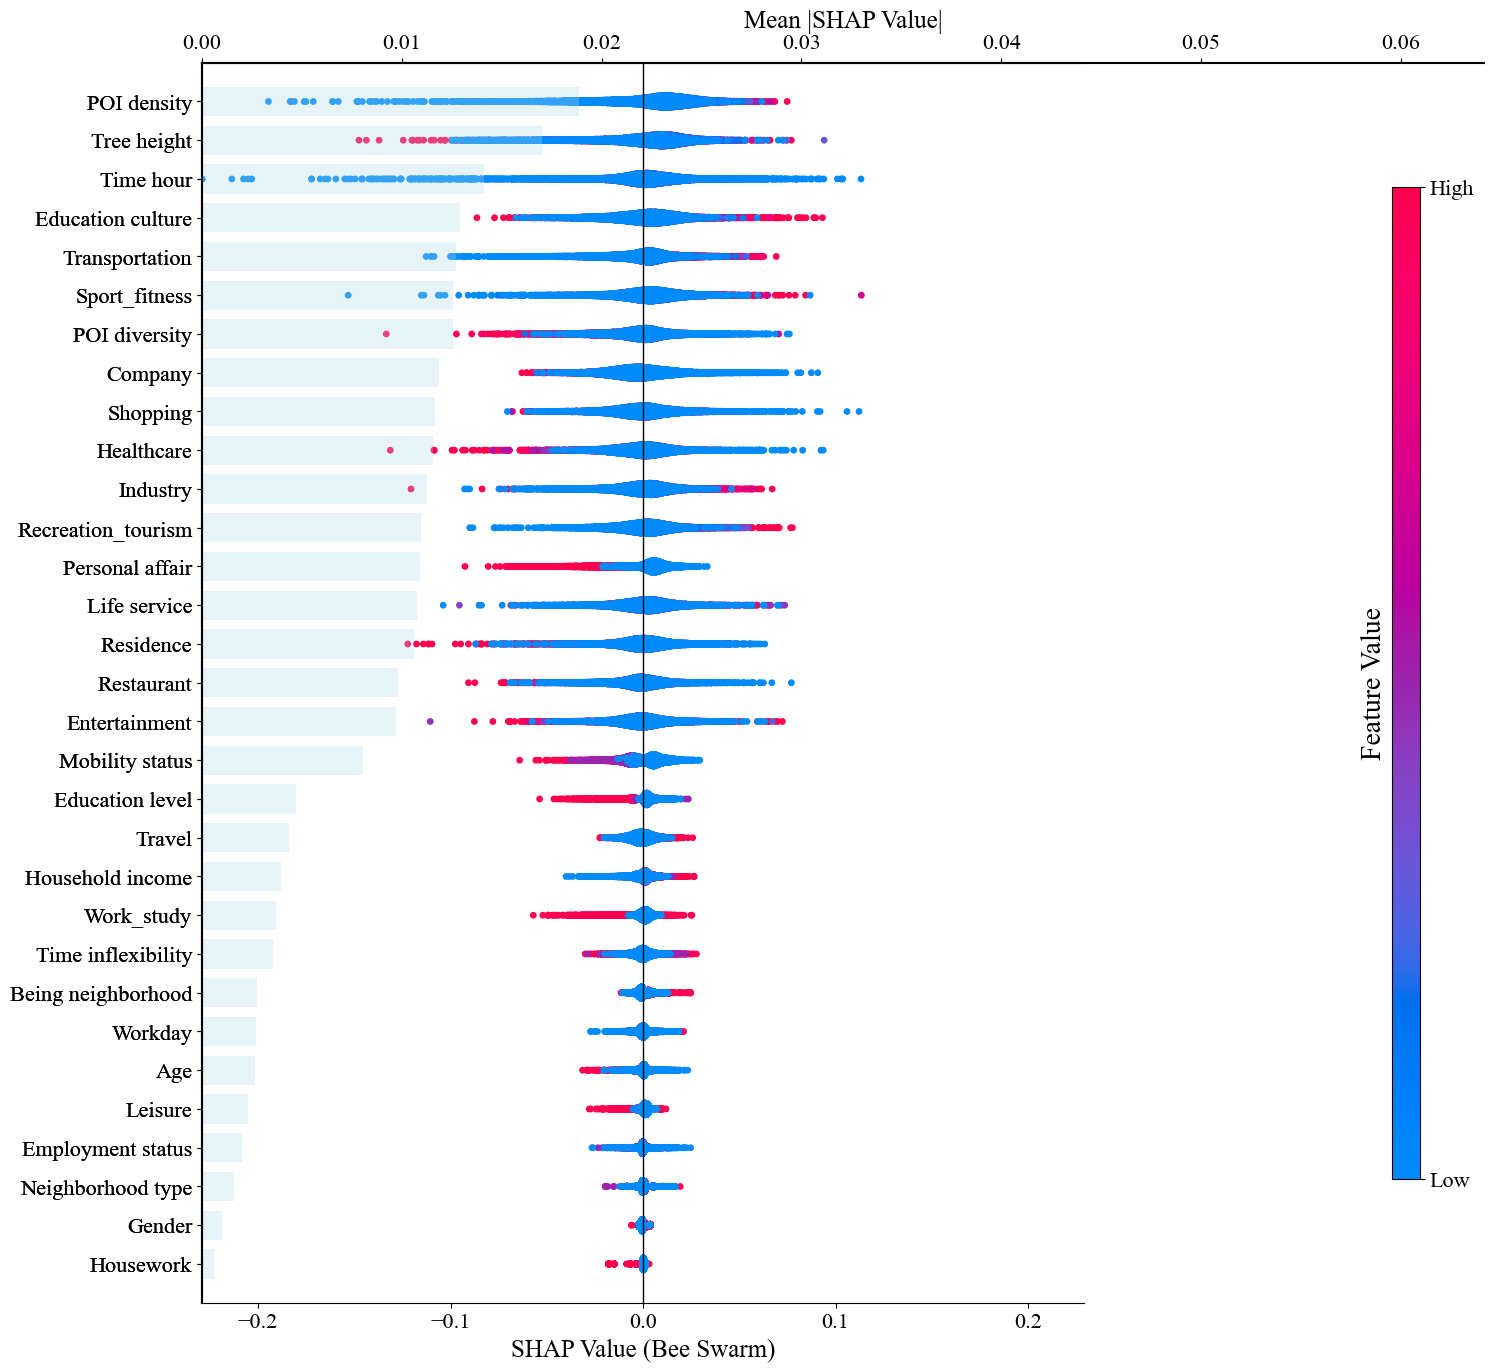

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import shap
import pandas as pd
from shap.plots.colors import red_blue

# Feature names
feature_names = [
    'Household income', 'Age', 'Gender', 'Education level', 'Employment status',
    'Neighborhood type', 'Work_study', 'Housework', 'Personal affair', 'Leisure',
    'Travel', 'Transportation', 'Residence', 'Industry', 'Company', 'Shopping',
    'Restaurant', 'Life service', 'Education culture', 'Entertainment', 'Sport_fitness',
    'Recreation_tourism', 'Healthcare', 'Workday', 'Time hour', 'Mobility status',
    'Time inflexibility', 'Being neighborhood', 'POI density', 'POI diversity',"Tree height"
]


data_=data[pred_vars]
# Ensure X_val_sample is a DataFrame
df = data_
#print(df)
# Compute mean absolute SHAP values and sort features
mean_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_mean_shap = mean_shap[sorted_idx]

# Plot settings
n_features = len(sorted_features)
bar_width_val = 42
bar_height = 1.5 * bar_width_val
spacing = 2 * bar_width_val
fig = plt.figure(figsize=(14, max(8, n_features * 0.5)))
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
max_shap = np.abs(shap_values).max() * 1
max_shap_bar = max_shap * 0.28

# Create axes
ax1 = fig.add_axes([0.10, 0.10, 0.63, 0.8])  # Bee swarm plot
ax2 = fig.add_axes([0.10, 0.10, 0.9157, 0.8], sharey=ax1, frameon=True)  # Bar plot
ax2.patch.set_alpha(0)
ax1.tick_params(axis='both', which='major', labelsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)

# Color settings
cmap = red_blue
norm = Normalize(vmin=0, vmax=1)

# Plot bee swarm for each feature
for i, idx in enumerate(sorted_idx):
    shap_vals = shap_values[:, idx]
    feature_vals = df.iloc[:, idx].values

    # Robust normalization using 10th and 90th percentiles
    cvals = feature_vals.astype(np.float64)
    vmin, vmax = np.percentile(cvals, [10, 90])
    cvals = (cvals - vmin) / (vmax - vmin + 1e-8)
    cvals = np.clip(cvals, 0, 1)

    # Sort points by cvals in descending order (red on top)
    sorted_order = np.argsort(cvals)[::-1]
    shap_vals = shap_vals[sorted_order]
    cvals = cvals[sorted_order]

    # Check for low variance to avoid KDE failure
    if np.std(shap_vals) < 1e-6:  # If variance is very low
        density = np.ones_like(shap_vals) * 0.3  # Use uniform density
    else:
        try:
            kde = gaussian_kde(shap_vals)
            density = kde(shap_vals) / np.max(kde(shap_vals)) * 0.3
        except np.linalg.LinAlgError:
            density = np.ones_like(shap_vals) * 0.3  # Fallback to uniform density

    # Scatter plot
    y_pos = (n_features - 1 - i) * spacing + np.random.uniform(-density, density, size=len(shap_vals)) * bar_width_val
    ax1.scatter(shap_vals, y_pos, c=cvals, cmap=cmap, alpha=1, s=15)

# Bar plot for mean SHAP values
bar_positions = np.arange(n_features)[::-1] * spacing
ax2.barh(bar_positions, sorted_mean_shap, height=bar_height, alpha=0.3, color='#ADD8E6')

# Axis settings
ax1.set_yticks(bar_positions)
ax1.set_yticklabels(sorted_features)
ax1.set_xlim(-max_shap, max_shap)
ax2.set_xlim(0, max_shap_bar)
ax1.axvline(0, color='k', linewidth=1)

# Axis styling
ax1.spines['right'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_visible(True)
    for spine in ['top', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.5)
ax1.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_ticks_position('top')

# Axis labels
ax1.set_xlabel('SHAP Value (Bee Swarm)', fontsize=18)
ax2.set_xlabel('Mean |SHAP Value|', fontsize=18)
ax2.xaxis.set_label_position('top')
ax2.xaxis.get_label().set_position((0.5, 20))
ax1.set_ylim(-spacing, n_features * spacing)
ax1.set_yticklabels(sorted_features, fontsize=16)

# Add colorbar
cbar_ax = fig.add_axes([0.95, 0.18, 0.02, 0.64])
sm = ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('right')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Feature Value', fontsize=20)

# Save and show
plt.savefig('shap_summary_plot_exposure_discordance.pdf', format='pdf', bbox_inches='tight')
plt.show()

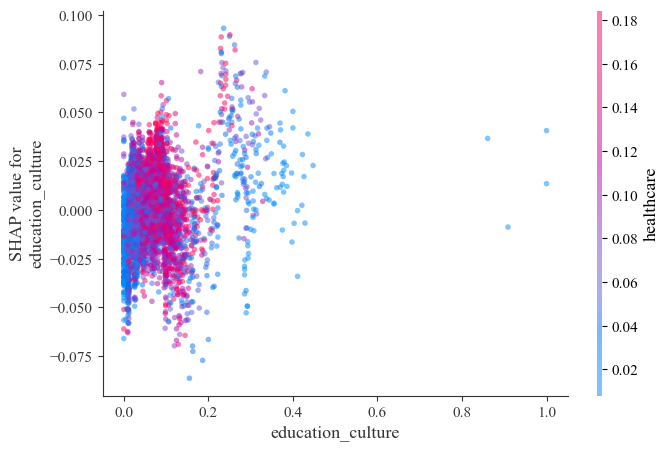

In [11]:
shap.dependence_plot('education_culture', shap_values, data[pred_vars], alpha=0.5)

In [23]:
shap_interaction_values = shap.TreeExplainer(gpbst).shap_interaction_values(data[pred_vars])

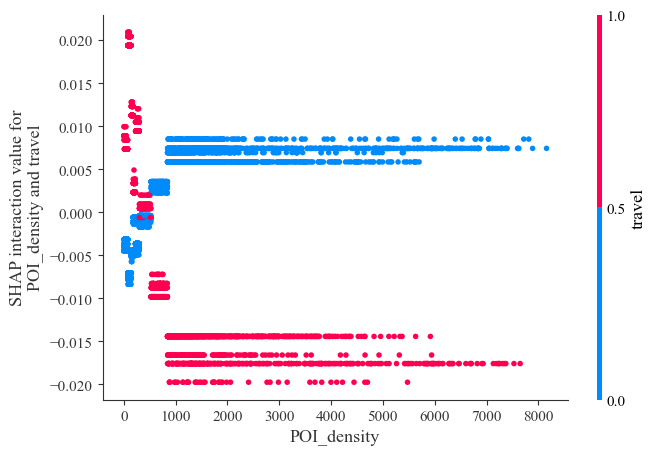

In [35]:
# Specify features for interaction plot
feature1 = 'POI_density'
feature2 = 'travel'


# # Create output directory if it doesn't exist
# interactions_dir = interactions_dir if 'interactions_dir' in locals() else './interactions'
# os.makedirs(interactions_dir, exist_ok=True)

# Generate SHAP dependence plot

shap.dependence_plot(
    (feature1, feature2),
    shap_interaction_values,
    df
)


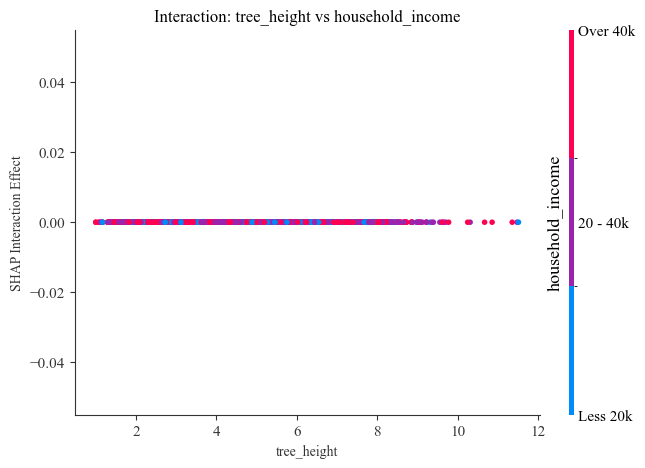

In [32]:
# Specify features for interaction plot
feature1 = 'tree_height'
feature2 = 'household_income'


# # Create output directory if it doesn't exist
# interactions_dir = interactions_dir if 'interactions_dir' in locals() else './interactions'
# os.makedirs(interactions_dir, exist_ok=True)

# Generate SHAP dependence plot

shap.dependence_plot(
    (feature1, feature2),
    shap_interaction_values,
    df,
    show=False
)

    

# Customize plot
plt.title(f"Interaction: {feature1} vs {feature2}", fontsize=12)
plt.xlabel(f"{feature1}", fontsize=10)
plt.ylabel("SHAP Interaction Effect", fontsize=10)

# Customize colorbar to show categorical values
cbar = plt.gcf().axes[-1]  # Get colorbar axis
cbar.set_yticks([1, 2, 3])  # Set ticks to categorical values
cbar.set_yticklabels(['Less 20k', '20 - 40k', 'Over 40k'])  # Custom labels
cbar.yaxis.set_label_position('left')
#cbar.set_title(f"{feature2}", fontsize=10)

# # Save plot with high resolution
# output_path = os.path.join(interactions_dir, f'interaction_{feature1}_vs_{feature2}.PDF')
# plt.savefig(output_path, dpi=800, bbox_inches='tight')
# print(f"Plot saved to {output_path}")


plt.show()